# Composing source models

Real scenes are rarely a single shape: a star with a disk, a companion that has its own circumstellar material, a binary inside a ring. `drpangloss` lets you build these from simple **building blocks** and combine them into a `System`.

The rules are short:

* every building block is a pure shape normalized to unit flux, with a `flux`, `dra` and `ddec`;
* a `System` mixes its named components by flux: $V = \sum_i f_i V_i / \sum_i f_i$;
* only flux *ratios* are measurable, so keep one component (usually the star) at `flux=1` and fit the others relative to it.

Everything else - grid searches, contrast maps, Laplace uncertainties and HMC - works on a composed model by naming parameters with **paths** such as `"comp.flux"`.

In [1]:
import sys
from itertools import combinations
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent
if str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

from drpangloss.grid_fit import (
    laplace_contrast_uncertainty_grid,
    likelihood_grid,
    optimized_contrast_grid,
)
from drpangloss.models import (
    BinaryModelCartesian,
    GaussianDisk,
    ModulatedGaussianRim,
    PointSource,
    System,
    UniformDisk,
    laplace_cov,
    numpyro_model,
)
from drpangloss.oidata import OIData, cp_indices
from drpangloss.plotting import plot_likelihood_grid


def show(ax, model, fov_mas, title, npix=128, saturate=None):
    """Render a model with East to the left and North up."""
    image = np.asarray(model.render(npix=npix, fov_mas=fov_mas))
    vmax = None if saturate is None else np.quantile(image, saturate)
    half = fov_mas / 2
    ax.imshow(image, extent=[half, -half, -half, half], cmap='magma', vmax=vmax)
    ax.set(title=title, xlabel='ΔRA (mas)', ylabel='ΔDec (mas)')

## Building blocks

`PointSource`, `GaussianDisk`, `UniformDisk` and `ModulatedGaussianRim` are the shapes currently available. Each one on its own is normalized to unit flux, and each has the same three placement parameters: `flux`, `dra` and `ddec`.

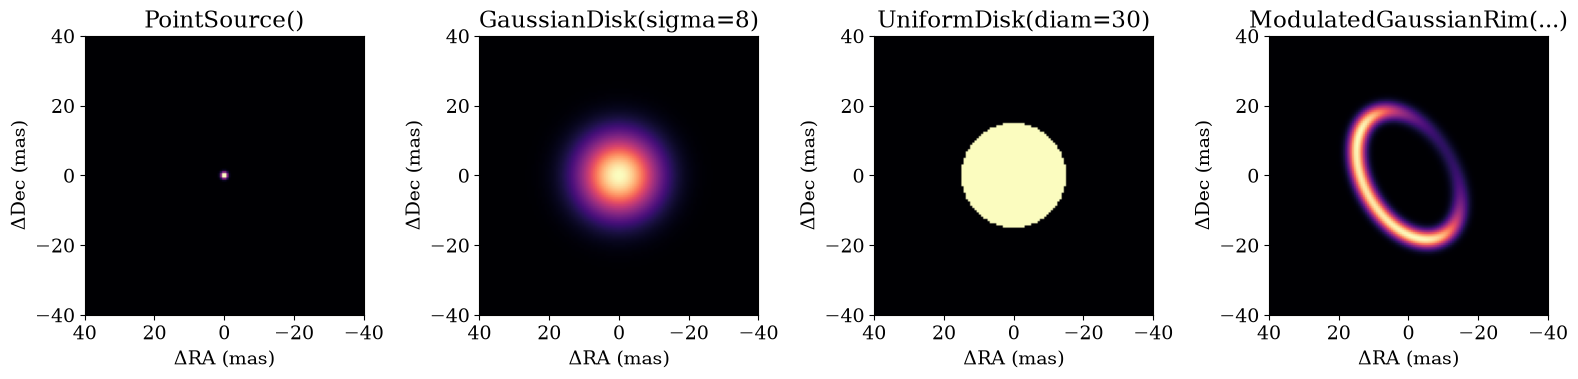

In [2]:
blocks = {
    'PointSource()': PointSource(),
    'GaussianDisk(sigma=8)': GaussianDisk(sigma=8.0),
    'UniformDisk(diam=30)': UniformDisk(diam=30.0),
    'ModulatedGaussianRim(...)': ModulatedGaussianRim(
        diam=40.0,
        fwhm=4.0,
        inc=50.0,
        pa=30.0,
        az_amps=jnp.array([0.7]),
        az_pas=jnp.array([120.0]),
    ),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, block) in zip(axes, blocks.items()):
    show(ax, block, 80.0, title)
plt.tight_layout()
plt.show()

**Takeaway:** building blocks are shapes; how bright they are only matters once you put them together.

## A synthetic observation

For the rest of the tutorial we simulate a nine-hole aperture-masking observation at 1.65 µm, with 1% squared-visibility errors and 0.3° closure-phase errors.

In [3]:
rng = np.random.default_rng(3)
holes = rng.uniform(-3.5, 3.5, size=(9, 2))
pairs = np.array(list(combinations(range(9), 2)))
triangles = np.array(list(combinations(range(9), 3)))
i_cps1, i_cps2, i_cps3 = cp_indices(pairs, triangles)
baselines = holes[pairs[:, 1]] - holes[pairs[:, 0]]

observation = OIData(
    {
        'u': jnp.array(baselines[:, 0]),
        'v': jnp.array(baselines[:, 1]),
        'wavel': jnp.array([1.65e-6]),
        'vis': jnp.ones(len(pairs)),
        'd_vis': jnp.full(len(pairs), 0.01),
        'phi': jnp.zeros(len(triangles)),
        'd_phi': jnp.full(len(triangles), 0.3),
        'phi_unit': 'deg',
        'i_cps1': i_cps1,
        'i_cps2': i_cps2,
        'i_cps3': i_cps3,
        'v2_flag': True,
        'cp_flag': True,
    }
)
print(f'{len(pairs)} baselines, {len(triangles)} closure phases')

36 baselines, 84 closure phases


## A binary, two ways

A binary is just a star plus a fainter point source. You can write it with the dedicated class or as a `System`; the observables are identical.

In [4]:
binary = BinaryModelCartesian(dra=60.0, ddec=-40.0, flux=0.02)
composed = System(
    star=PointSource(),
    comp=PointSource(dra=60.0, ddec=-40.0, flux=0.02),
)

difference = jnp.max(jnp.abs(observation.model(binary) - observation.model(composed)))
print(f'largest difference in observables: {float(difference):.1e}')

largest difference in observables: 2.4e-07


**Takeaway:** for a plain binary, keep using `BinaryModelCartesian` or `BinaryModelAngular` - they are the fastest path and everything in the binary tutorials is unchanged. Reach for `System` when the scene needs more than two points.

## A star with a rim

Here a modulated rim has half the star's flux. You can name the components explicitly, or use the `+` and `*` shortcuts: `+` builds a `System`, and `k * component` multiplies that component's flux by `k`.

component names from +: ['c0', 'c1']


same observables: True


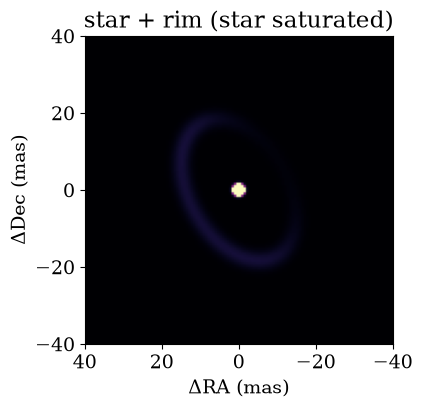

In [5]:
rim_shape = dict(
    diam=40.0,
    fwhm=4.0,
    inc=50.0,
    pa=30.0,
    az_amps=jnp.array([0.7]),
    az_pas=jnp.array([120.0]),
)

explicit = System(star=PointSource(), rim=ModulatedGaussianRim(**rim_shape, flux=0.5))
shortcut = PointSource() + 0.5 * ModulatedGaussianRim(**rim_shape)

print('component names from +:', list(shortcut.components))
print('same observables:', bool(jnp.allclose(observation.model(explicit), observation.model(shortcut))))

fig, ax = plt.subplots(figsize=(5, 4))
show(ax, explicit, 80.0, 'star + rim (star saturated)', saturate=0.999)
plt.show()

**Takeaway:** the shortcuts are handy for quick experiments; `System(name=...)` gives readable names, which matter once you start fitting.

## Nesting: a companion with its own disk

A `System` can itself be a component. Its `flux` is the total flux of the group relative to its siblings, and its `dra`/`ddec` move the whole group together. Here the companion group has 30% of the star's flux, and inside it the disk has half the flux of the companion's core.

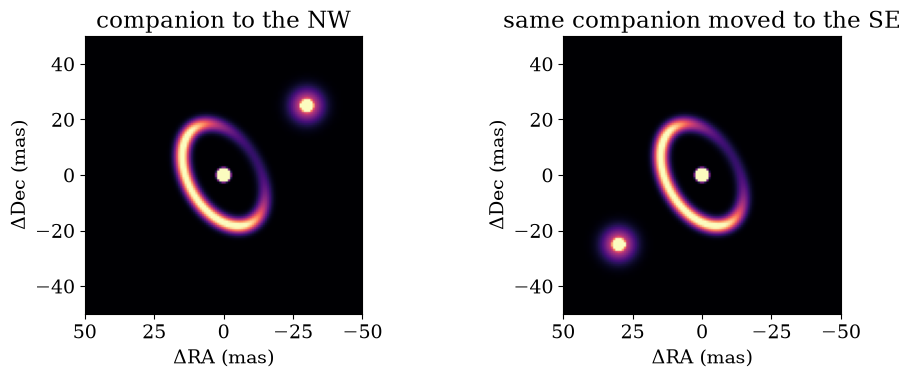

In [6]:
companion = System(
    core=PointSource(),
    disk=GaussianDisk(sigma=4.0, flux=0.5),
    dra=-30.0,
    ddec=25.0,
    flux=0.3,
)
scene = System(star=PointSource(), rim=ModulatedGaussianRim(**rim_shape, flux=0.5), comp=companion)
moved = scene.set(['comp.dra', 'comp.ddec'], [30.0, -25.0])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show(axes[0], scene, 100.0, 'companion to the NW', saturate=0.99)
show(axes[1], moved, 100.0, 'same companion moved to the SE', saturate=0.99)
plt.tight_layout()
plt.show()

**Takeaway:** nesting lets you describe structure hierarchically and move or reweight a whole group with one parameter.

## Parameter paths

Every parameter has a dot-separated path made of component names. You can read it as an attribute, `get` it, or `set` it; `set` returns a new model and leaves the original unchanged.

In [7]:
print(f'scene.comp.disk.sigma  = {float(scene.comp.disk.sigma):g}')
print(f"scene.get('comp.flux') = {float(scene.get('comp.flux')):g}")

brighter = scene.set('comp.flux', 0.6)
print(f'original comp.flux     = {float(scene.comp.flux):g}')
print(f'updated comp.flux      = {float(brighter.comp.flux):g}')

scene.comp.disk.sigma  = 4
scene.get('comp.flux') = 0.3
original comp.flux     = 0.3
updated comp.flux      = 0.6


**Takeaway:** paths are how the fitting tools address the parameters you want to vary.

## Searching for a companion around a star with a rim

Now a realistic use: the star and rim are known, and we search for a faint companion. We simulate data from the truth, then give the grid tools a **template** model and a grid keyed by paths. The same functions you use for binaries take the template in place of a model class.

grid best: {'comp.dra': 43.3333, 'comp.ddec': 33.3333, 'comp.flux': 0.01}


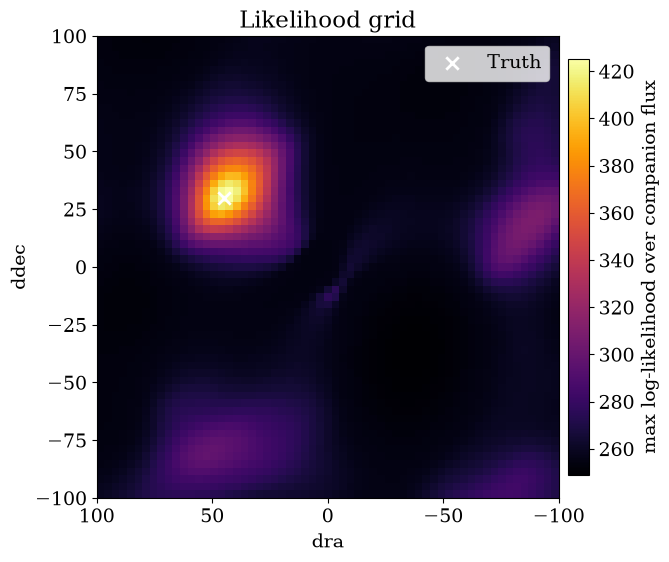

In [8]:
rim = ModulatedGaussianRim(**rim_shape, flux=0.5)
truth = System(star=PointSource(), rim=rim, comp=PointSource(dra=45.0, ddec=30.0, flux=0.01))
data = observation.with_model(truth, key=jax.random.PRNGKey(0))

search = System(star=PointSource(), rim=rim, comp=PointSource(flux=1e-3))
grid = {
    'comp.dra': jnp.linspace(-100.0, 100.0, 61),
    'comp.ddec': jnp.linspace(-100.0, 100.0, 61),
    'comp.flux': 10.0 ** jnp.linspace(-3.5, -1.0, 16),
}
loglike_grid = likelihood_grid(data, search, grid)

best = jnp.unravel_index(jnp.argmax(loglike_grid), loglike_grid.shape)
best_values = [float(grid[key][index]) for key, index in zip(grid, best)]
print('grid best:', {key: round(value, 4) for key, value in zip(grid, best_values)})

axes_for_plot = {'dra': grid['comp.dra'], 'ddec': grid['comp.ddec'], 'flux': grid['comp.flux']}
plot_likelihood_grid(
    loglike_grid.max(axis=2),
    axes_for_plot,
    truths={'dra': 45.0, 'ddec': 30.0},
    colorbar_label='max log-likelihood over companion flux',
)
plt.show()

The contrast tools work the same way. `optimized_contrast_grid` finds the best companion flux at every position, and `laplace_contrast_uncertainty_grid` gives its uncertainty, so their ratio is a detection significance map. The grid tools recognise the parameter ending in `.flux` as the one to optimize. Sparse aperture masks produce fainter alias peaks; the real companion is the strongest one.

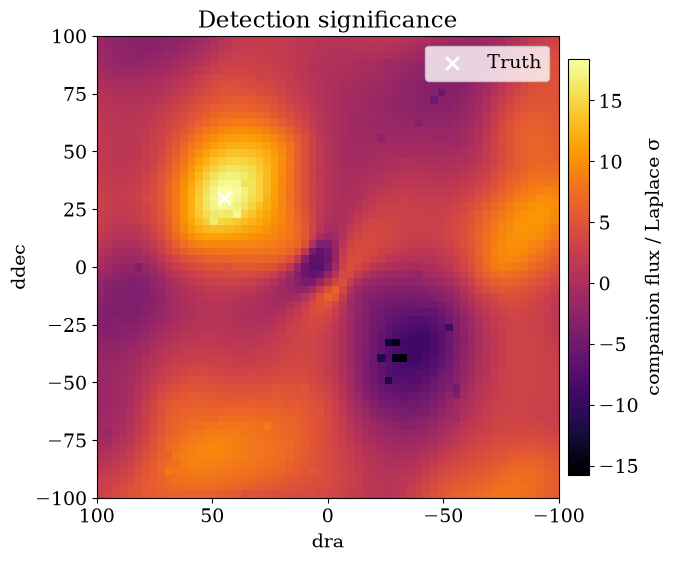

In [9]:
best_flux = optimized_contrast_grid(data, search, grid)
best_flux_indices = jnp.argmax(loglike_grid, axis=2)
flux_sigma = laplace_contrast_uncertainty_grid(best_flux_indices, data, search, grid)
snr = best_flux / flux_sigma

fig, ax = plot_likelihood_grid(
    snr,
    axes_for_plot,
    truths={'dra': 45.0, 'ddec': 30.0},
    colorbar_label='companion flux / Laplace σ',
)
ax.set_title('Detection significance')
plt.show()

**Takeaway:** a composed search is written exactly like a binary search - only the template and the path names change.

## Uncertainties: Laplace and HMC

`laplace_cov` takes the same template and paths. For HMC, `numpyro_model` turns a template and a dictionary of `{path: prior}` into a numpyro model, using each path as the sample-site name.

In [10]:
paths = list(grid)
covariance = laplace_cov(jnp.array(best_values), paths, data, search)
laplace_sigma = jnp.sqrt(jnp.diag(covariance))

priors = {
    'comp.dra': dist.Uniform(-100.0, 100.0),
    'comp.ddec': dist.Uniform(-100.0, 100.0),
    'comp.flux': dist.LogUniform(1e-4, 1e-1),
}
kernel = NUTS(
    numpyro_model(search, priors, data),
    init_strategy=init_to_value(values=dict(zip(paths, best_values))),
)
mcmc = MCMC(kernel, num_warmup=300, num_samples=500, progress_bar=False)
mcmc.run(jax.random.PRNGKey(1))
posterior = mcmc.get_samples()

truth_values = {'comp.dra': 45.0, 'comp.ddec': 30.0, 'comp.flux': 0.01}
for path, sigma in zip(paths, laplace_sigma):
    samples = posterior[path]
    print(
        f'{path:10s} truth {truth_values[path]:8.4f}   '
        f'HMC {float(jnp.median(samples)):8.4f} ± {float(jnp.std(samples)):.4f}   '
        f'Laplace σ {float(sigma):.4f}'
    )

comp.dra   truth  45.0000   HMC  44.4603 ± 0.9739   Laplace σ 1.0422
comp.ddec  truth  30.0000   HMC  31.5011 ± 1.0711   Laplace σ 1.0782
comp.flux  truth   0.0100   HMC   0.0103 ± 0.0006   Laplace σ 0.0006


**Takeaway:** Laplace and HMC agree, and both recover the truth; neither needed a custom model function.

## Things to watch out for

* **Fix one flux.** Only flux ratios are measurable. Leave the reference component (usually the star) at `flux=1`; if you vary every flux, the overall scale is unconstrained.
* **`k * binary` wraps the binary.** `BinaryModelCartesian.flux` already means companion/primary, so multiplying a binary by `k` gives `System(c0=binary, flux=k)` rather than changing its companion.
* **Which flux is optimized.** Grid and contrast tools use a parameter named exactly `flux`, otherwise the single path ending in `.flux`. If several paths end in `.flux`, put the one to optimize last in the grid dictionary.
* **Names.** `+` names components `c0`, `c1`, ...; use `System(star=..., comp=...)` when you want meaningful paths.
* **Rendering.** `System.render` works for the building blocks and nested systems. Use `PointSource` components rather than `BinaryModelCartesian` inside a `System` if you want to render it.